# Partie 1 — Data Science & Baseline ML
## Jalon 1 & 2 : Chargement du Dataset FER2013 + EDA
**Auteur : Hassan HOUSSEIN HOUMED**

In [7]:
import sys
sys.path.append('../src')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import download_fer2013, get_data_path
from utils import EMOTIONS, plot_emotion_distribution, save_figure

print('Imports OK')

Imports OK


### 2. Téléchargement du Dataset

In [8]:
download_fer2013(dest_folder='../data/raw')
DATA_PATH = '../data/raw'

Téléchargement du dataset FER2013...
Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
Dataset téléchargé dans : ../data/raw


### 3. Exploration de la structure du dataset

In [9]:
# Structure du dataset
for split in ['train', 'test']:
    print(f'\n {split}:')
    for emotion in EMOTIONS:
        path = os.path.join(DATA_PATH, split, emotion)
        if os.path.exists(path):
            count = len(os.listdir(path))
            print(f'  {emotion}: {count} images')


 train:
  Angry: 3995 images
  Disgust: 436 images
  Fear: 4097 images
  Happy: 7215 images
  Sad: 4830 images
  Surprise: 3171 images
  Neutral: 4965 images

 test:
  Angry: 958 images
  Disgust: 111 images
  Fear: 1024 images
  Happy: 1774 images
  Sad: 1247 images
  Surprise: 831 images
  Neutral: 1233 images


### 4. Distribution des émotions

Figure sauvegardée : notebooks/figures/distribution_emotions.png


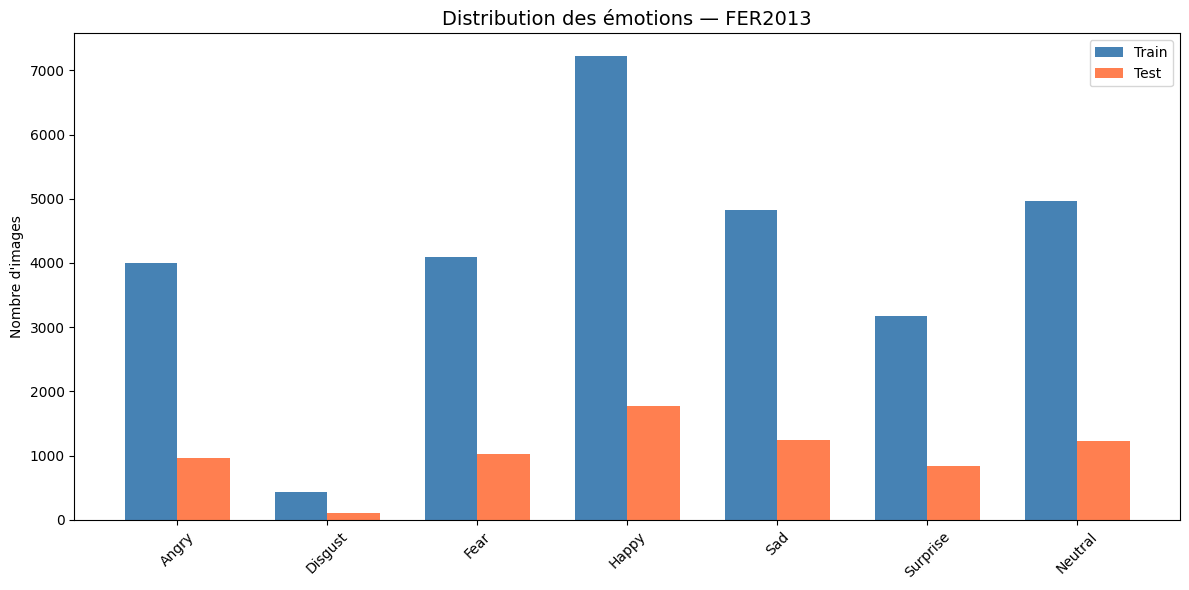


 Classe la plus représentée : Happy (7215 images)
 Classe la moins représentée : Disgust (436 images)
 Ratio déséquilibre : 16.5x


In [10]:
# Compter les images par émotion
train_counts = []
test_counts = []

for emotion in EMOTIONS:
    train_path = os.path.join(DATA_PATH, 'train', emotion)
    test_path = os.path.join(DATA_PATH, 'test', emotion)
    train_counts.append(len(os.listdir(train_path)) if os.path.exists(train_path) else 0)
    test_counts.append(len(os.listdir(test_path)) if os.path.exists(test_path) else 0)

# Visualisation
x = np.arange(len(EMOTIONS))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, train_counts, width, label='Train', color='steelblue')
bars2 = ax.bar(x + width/2, test_counts, width, label='Test', color='coral')

ax.set_title('Distribution des émotions — FER2013', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(EMOTIONS, rotation=45)
ax.set_ylabel("Nombre d'images")
ax.legend()
plt.tight_layout()
save_figure('distribution_emotions.png')
plt.show()

print(f"\n Classe la plus représentée : Happy ({max(train_counts)} images)")
print(f" Classe la moins représentée : Disgust ({min(train_counts)} images)")
print(f" Ratio déséquilibre : {max(train_counts)/min(train_counts):.1f}x")

### 5. Visualisation d'exemples d'images par émotion

Figure sauvegardée : notebooks/figures/exemples_images.png


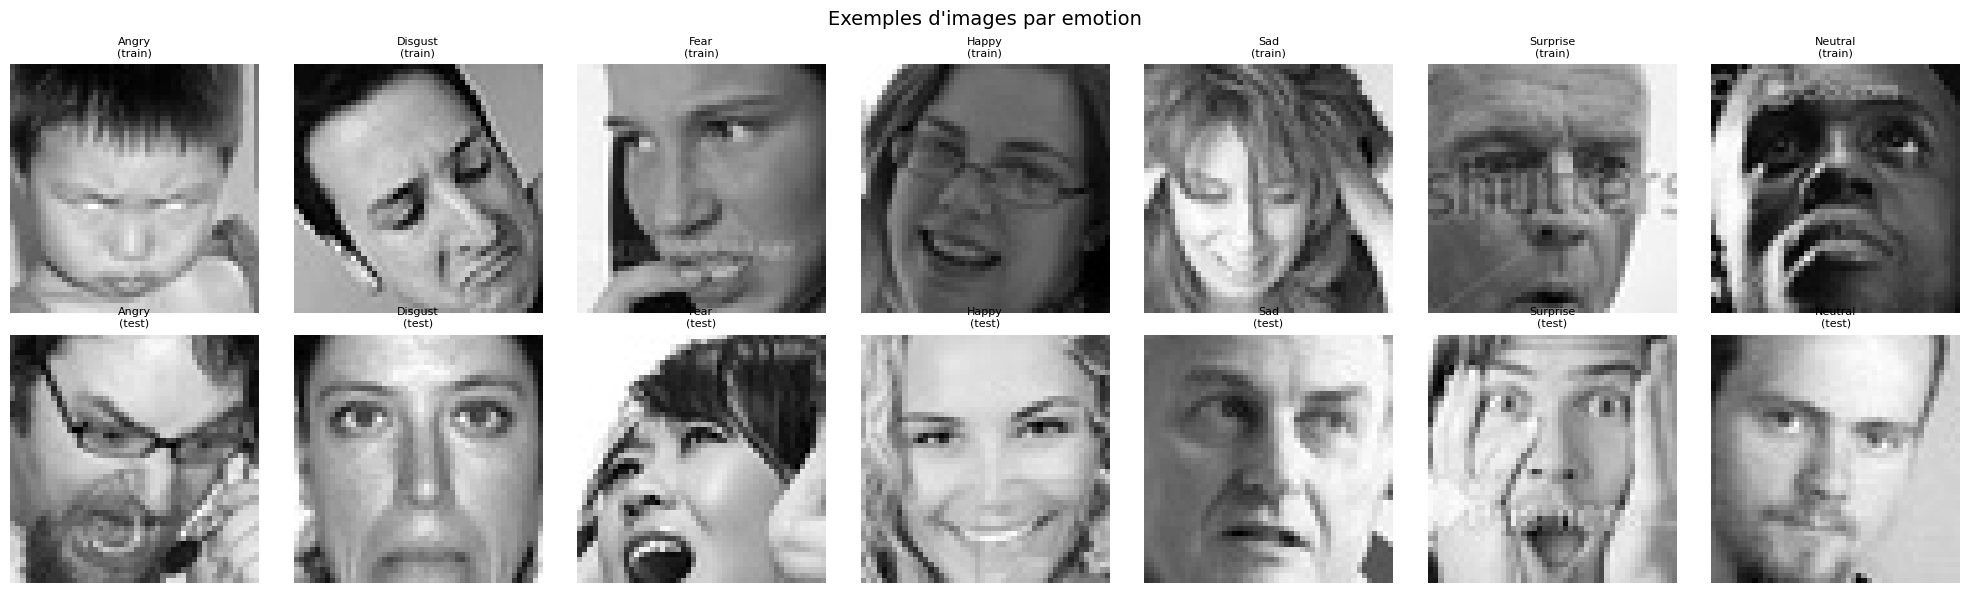

In [11]:
from PIL import Image

fig, axes = plt.subplots(2, 7, figsize=(20, 6))

for i, emotion in enumerate(EMOTIONS):
    for j, split in enumerate(['train', 'test']):
        path = os.path.join(DATA_PATH, split, emotion)
        if os.path.exists(path):
            img_file = os.listdir(path)[0]
            img = Image.open(os.path.join(path, img_file))
            axes[j, i].imshow(img, cmap='gray')
            axes[j, i].set_title(f'{emotion}\n({split})', fontsize=8)
            axes[j, i].axis('off')

plt.suptitle("Exemples d'images par emotion", fontsize=14)
plt.tight_layout()
save_figure('exemples_images.png')
plt.show()

### 6. Statistiques descriptives

In [12]:
# Resume statistique
df_stats = pd.DataFrame({
    'Emotion': EMOTIONS,
    'Train': train_counts,
    'Test': test_counts,
    'Total': [t+v for t,v in zip(train_counts, test_counts)]
})
df_stats['% Train'] = (df_stats['Train'] / df_stats['Train'].sum() * 100).round(2)
df_stats['% Test'] = (df_stats['Test'] / df_stats['Test'].sum() * 100).round(2)

print('Statistiques FER2013:')
print(df_stats.to_string(index=False))
print(f'\nTotal images      : {df_stats["Total"].sum()}')
print(f'Total train       : {df_stats["Train"].sum()}')
print(f'Total test        : {df_stats["Test"].sum()}')
print(f'Ratio train/test  : {df_stats["Train"].sum()/df_stats["Test"].sum():.2f}')
print(f'Ecart-type train  : {df_stats["Train"].std():.0f} images')

Statistiques FER2013:
 Emotion  Train  Test  Total  % Train  % Test
   Angry   3995   958   4953    13.92   13.35
 Disgust    436   111    547     1.52    1.55
    Fear   4097  1024   5121    14.27   14.27
   Happy   7215  1774   8989    25.13   24.71
     Sad   4830  1247   6077    16.82   17.37
Surprise   3171   831   4002    11.05   11.58
 Neutral   4965  1233   6198    17.29   17.18

Total images      : 35887
Total train       : 28709
Total test        : 7178
Ratio train/test  : 4.00
Ecart-type train  : 2053 images


### 7. Analyse du desequilibre des classes

Figure sauvegardée : notebooks/figures/desequilibre_classes.png


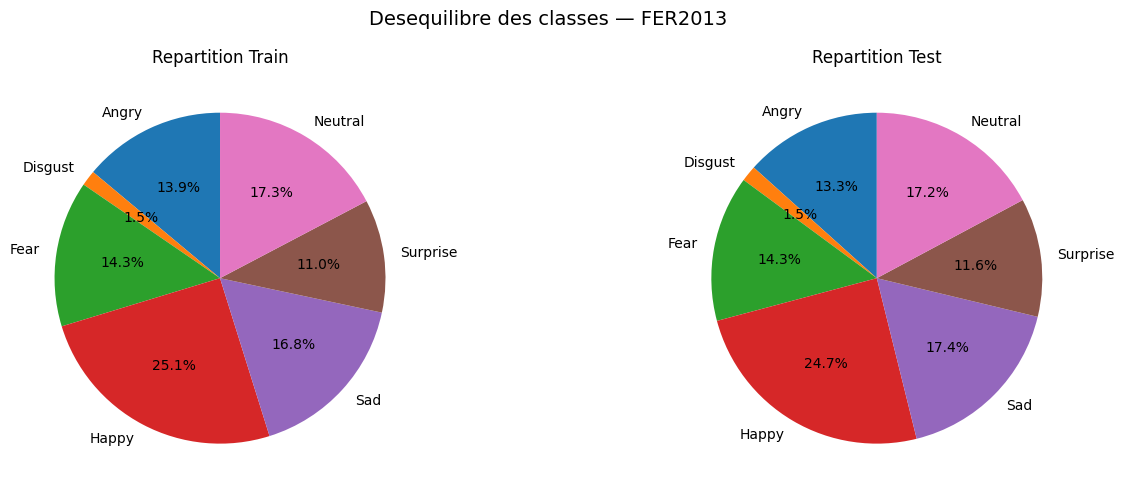

Analyse du desequilibre :
  - Disgust represente seulement 1.52% des donnees train
  - Happy est 16.5x plus represente que Disgust
  - Ce desequilibre peut biaiser le modele vers les classes majoritaires
  - Solution envisagee : class_weight ou data augmentation sur les classes minoritaires


In [13]:
# Visualisation du desequilibre
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Camembert Train
axes[0].pie(train_counts, labels=EMOTIONS, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Repartition Train')

# Camembert Test
axes[1].pie(test_counts, labels=EMOTIONS, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Repartition Test')

plt.suptitle('Desequilibre des classes — FER2013', fontsize=14)
plt.tight_layout()
save_figure('desequilibre_classes.png')
plt.show()

# Analyse
total_train = sum(train_counts)
print('Analyse du desequilibre :')
print(f'  - Disgust represente seulement {436/total_train*100:.2f}% des donnees train')
print(f'  - Happy est 16.5x plus represente que Disgust')
print(f'  - Ce desequilibre peut biaiser le modele vers les classes majoritaires')
print(f'  - Solution envisagee : class_weight ou data augmentation sur les classes minoritaires')

### 8. Analyse des pixels et qualite des images

Analyse des pixels :
  Taille des images     : 48x48 pixels
  Valeur min moyenne    : 8.65
  Valeur max moyenne    : 234.08
  Moyenne globale       : 129.85
  Ecart-type global     : 64.56
Figure sauvegardée : notebooks/figures/distribution_pixels.png


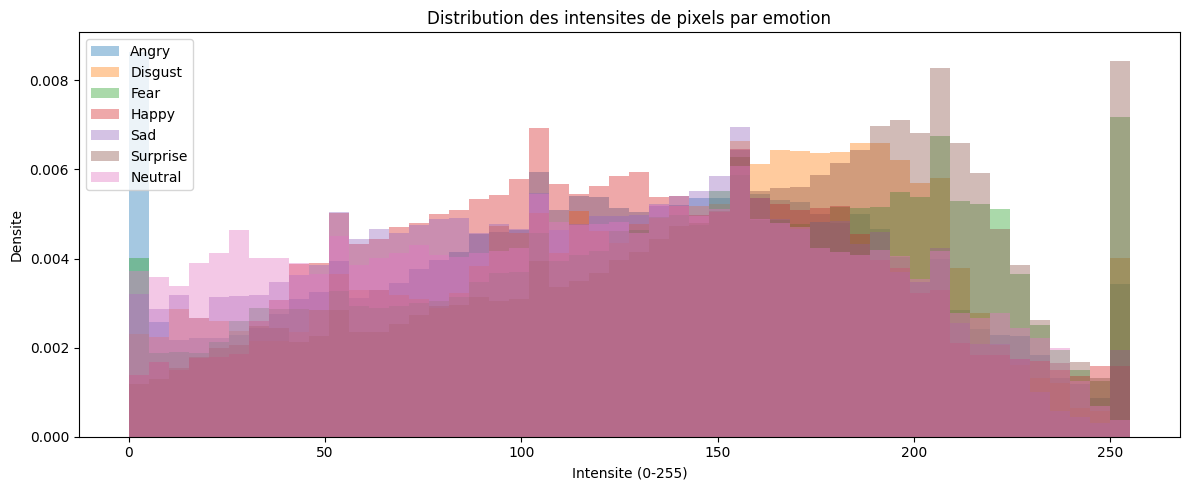

In [14]:
# Analyse des pixels sur un echantillon
sample_pixels = []
sample_labels = []

for i, emotion in enumerate(EMOTIONS):
    path = os.path.join(DATA_PATH, 'train', emotion)
    files = os.listdir(path)[:50]  # 50 images par emotion
    for f in files:
        img = np.array(Image.open(os.path.join(path, f)).convert('L'))
        sample_pixels.append(img.flatten())
        sample_labels.append(emotion)

sample_pixels = np.array(sample_pixels)

# Statistiques sur les pixels
print('Analyse des pixels :')
print(f'  Taille des images     : 48x48 pixels')
print(f'  Valeur min moyenne    : {sample_pixels.min(axis=1).mean():.2f}')
print(f'  Valeur max moyenne    : {sample_pixels.max(axis=1).mean():.2f}')
print(f'  Moyenne globale       : {sample_pixels.mean():.2f}')
print(f'  Ecart-type global     : {sample_pixels.std():.2f}')

# Distribution des intensites
fig, ax = plt.subplots(figsize=(12, 5))
for i, emotion in enumerate(EMOTIONS):
    emotion_pixels = sample_pixels[np.array(sample_labels) == emotion].flatten()
    ax.hist(emotion_pixels, bins=50, alpha=0.4, label=emotion, density=True)

ax.set_title('Distribution des intensites de pixels par emotion')
ax.set_xlabel('Intensite (0-255)')
ax.set_ylabel('Densite')
ax.legend()
plt.tight_layout()
save_figure('distribution_pixels.png')
plt.show()

### 9. Nettoyage et detection des anomalies

In [16]:
# Detection des anomalies sur un echantillon
anomalies = []
tailles = set()
total_verifies = 0

for emotion in EMOTIONS:
    path = os.path.join(DATA_PATH, 'train', emotion)
    fichiers = os.listdir(path)[:100]  # 100 images par emotion suffit
    for f in fichiers:
        filepath = os.path.join(path, f)
        try:
            img = Image.open(filepath).convert('L')
            w, h = img.size
            tailles.add((w, h))
            if (w, h) != (48, 48):
                anomalies.append({'fichier': f, 'emotion': emotion, 'taille': (w, h)})
            total_verifies += 1
        except Exception as e:
            anomalies.append({'fichier': f, 'emotion': emotion, 'erreur': str(e)})

print('Analyse des anomalies :')
print(f'  Images verifiees      : {total_verifies}')
print(f'  Tailles trouvees      : {tailles}')
print(f'  Images anormales      : {len(anomalies)}')

if len(anomalies) == 0:
    print('  Aucune anomalie detectee, dataset propre')

Analyse des anomalies :
  Images verifiees      : 700
  Tailles trouvees      : {(48, 48)}
  Images anormales      : 0
  Aucune anomalie detectee, dataset propre


### 10. Augmentation de donnees

Figure sauvegardée : notebooks/figures/augmentation.png


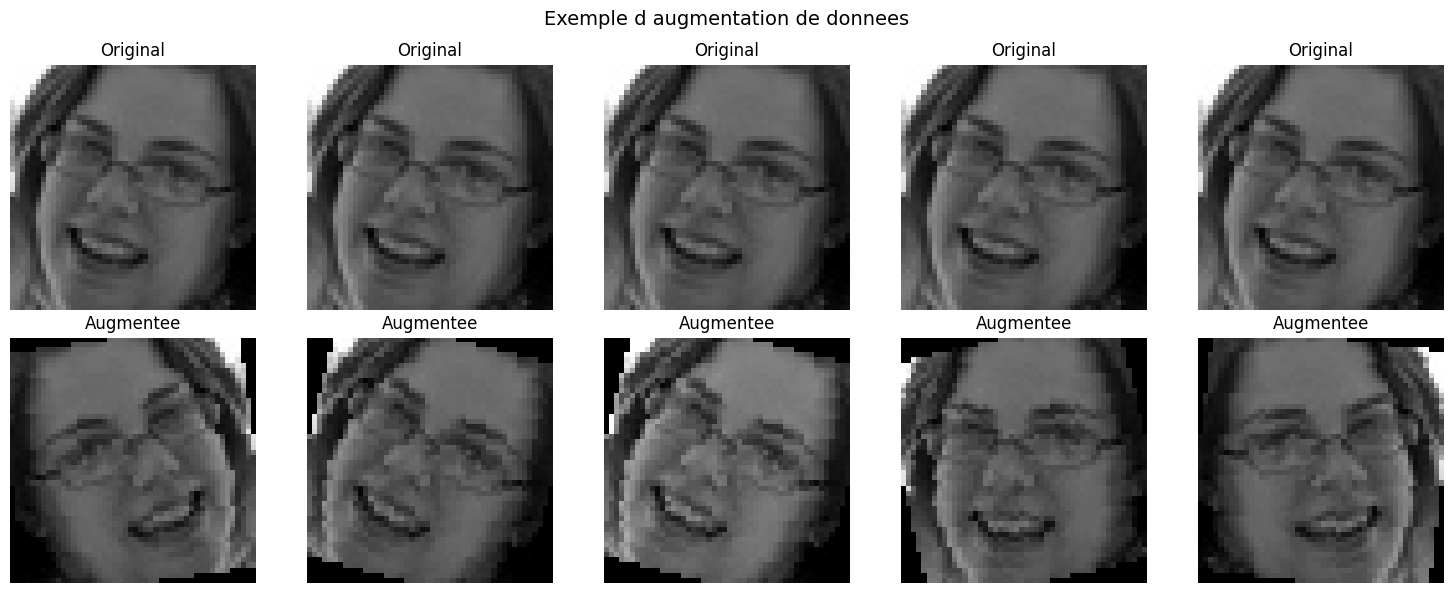

Transformations appliquees :
  - Rotation aleatoire entre -15 et +15 degres
  - Flip horizontal aleatoire (50% de chance)
  - Variation de luminosite entre 0.8 et 1.2
  - Objectif : reduire le surapprentissage sur les classes majoritaires


In [17]:
from PIL import ImageEnhance, ImageOps
import random

def augment_image(img):
    """Applique des transformations aleatoires sur une image."""
    # Rotation aleatoire
    angle = random.uniform(-15, 15)
    img = img.rotate(angle)
    
    # Flip horizontal aleatoire
    if random.random() > 0.5:
        img = ImageOps.mirror(img)
    
    # Luminosite aleatoire
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(random.uniform(0.8, 1.2))
    
    return img

# Visualisation des augmentations
sample_path = os.path.join(DATA_PATH, 'train', 'Happy')
sample_img = Image.open(os.path.join(sample_path, os.listdir(sample_path)[0])).convert('L')

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Ligne 1 : image originale
for i in range(5):
    axes[0, i].imshow(sample_img, cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')

# Ligne 2 : images augmentees
for i in range(5):
    aug_img = augment_image(sample_img)
    axes[1, i].imshow(aug_img, cmap='gray')
    axes[1, i].set_title('Augmentee')
    axes[1, i].axis('off')

plt.suptitle('Exemple d augmentation de donnees', fontsize=14)
plt.tight_layout()
save_figure('augmentation.png')
plt.show()

print('Transformations appliquees :')
print('  - Rotation aleatoire entre -15 et +15 degres')
print('  - Flip horizontal aleatoire (50% de chance)')
print('  - Variation de luminosite entre 0.8 et 1.2')
print('  - Objectif : reduire le surapprentissage sur les classes majoritaires')

### 11. Preparation des donnees pour le Baseline ML

In [18]:
# Chargement et normalisation des donnees
def load_dataset(data_path, split='train', max_per_class=500):
    """
    Charge les images et les labels depuis le dataset.
    Limite a max_per_class images par emotion pour la baseline ML.
    """
    X, y = [], []
    
    for label, emotion in enumerate(EMOTIONS):
        path = os.path.join(data_path, split, emotion)
        fichiers = os.listdir(path)[:max_per_class]
        for f in fichiers:
            img = np.array(
                Image.open(os.path.join(path, f)).convert('L')
            ).flatten()  # 48x48 = 2304 features
            X.append(img)
            y.append(label)
    
    return np.array(X), np.array(y)

print('Chargement des donnees train...')
X_train, y_train = load_dataset(DATA_PATH, 'train', max_per_class=500)

print('Chargement des donnees test...')
X_test, y_test = load_dataset(DATA_PATH, 'test', max_per_class=150)

# Normalisation entre 0 et 1
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f'\nDonnees chargees :')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  y_train : {y_train.shape}')
print(f'  y_test  : {y_test.shape}')

Chargement des donnees train...
Chargement des donnees test...

Donnees chargees :
  X_train : (3436, 2304)
  X_test  : (1011, 2304)
  y_train : (3436,)
  y_test  : (1011,)


### 12. Sauvegarde des donnees preparees

In [19]:
import pickle

# Sauvegarde des donnees preparees
os.makedirs('../data/processed', exist_ok=True)

with open('../data/processed/data.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'emotions': EMOTIONS
    }, f)

print('Donnees sauvegardees dans data/processed/data.pkl')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')

Donnees sauvegardees dans data/processed/data.pkl
  X_train : (3436, 2304)
  X_test  : (1011, 2304)
